# Monitor Comparison: LSTM-PPO vs NSGD

This notebook compares four monitor CSV files using the shared monitor schema:

- LSTM-PPO 6 hours: edit `LSTM_PPO_6H_CSV`
- LSTM-PPO 48 hours: edit `LSTM_PPO_48H_CSV`
- NSGD 6 hours: edit `NSGD_6H_CSV`
- NSGD 48 hours: edit `NSGD_48H_CSV`

It validates the expected columns, normalizes timestamps, builds summary tables, plots time-series comparisons, and saves figures under `monitor comparison`.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
})

# Fill these paths manually before running the notebook.
LSTM_PPO_6H_CSV = '/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/logs/rl_last_final_train_after_6_hours_eval_last_last/monitor.csv'
LSTM_PPO_48H_CSV = '/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/logs/rl_last_final_train_after_48_hours_eval_last_last/monitor.csv'
NSGD_6H_CSV = '/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/logs/nsgd_last_run_after_6_hours/monitor.csv'
NSGD_48H_CSV = '/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/logs/nsgd_last_run_after_48_hours_evaluate/monitor.csv'

MONITOR_CSVS = {
    'LSTM-PPO 6h': LSTM_PPO_6H_CSV,
    'LSTM-PPO 48h': LSTM_PPO_48H_CSV,
    'NSGD 6h': NSGD_6H_CSV,
    'NSGD 48h': NSGD_48H_CSV,
}

OUT_DIR = '/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/monitor comparison'
os.makedirs(OUT_DIR, exist_ok=True)

COLOR_LSTM = '#FF6F00'
COLOR_NSGD = '#2196F3'
LABEL_LSTM = 'LSTM-PPO'
LABEL_NSGD = 'NSGD'
BUCKET_SECONDS = 30
WINDOW_MINUTES = 90

# Monitor-derived cost weights used for charting when no valid cost series is available.
W_IDLE_ON = 2
W_BUSY = 1
W_INIT = 5
W_RESERVED = 100
W_REJ = 200

EXPECTED_COLUMNS = [
    'timestamp', 'datetime', 'cold', 'idle_on', 'busy',
    'init_total', 'init_free', 'init_reserved', 'nsgd_cost',
    'has_rejection', 'total_pods', 'ready_pods', 'not_ready_pods',
    'inflight_requests', 'rejected_requests_interval',
    'rejected_requests', 'latest_cost', 'cost_delta',
    'iteration', 'phase',
]


## Load And Validate Data

In [4]:
def validate_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing CSV file: {path}')


def load_monitor_csv(path, label):
    validate_file(path)
    df = pd.read_csv(path)
    missing = [col for col in EXPECTED_COLUMNS if col not in df.columns]
    extra = [col for col in df.columns if col not in EXPECTED_COLUMNS]

    print(f'{label}: {len(df):,} rows, {len(df.columns)} columns')
    if missing:
        print(f'{label} missing columns: {missing}')
    else:
        print(f'{label}: all expected columns are present')
    if extra:
        print(f'{label} extra columns: {extra}')

    return df


monitor_raw = {
    label: load_monitor_csv(path, label)
    for label, path in MONITOR_CSVS.items()
}

lstm_6h_raw = monitor_raw['LSTM-PPO 6h']
lstm_48h_raw = monitor_raw['LSTM-PPO 48h']
nsgd_6h_raw = monitor_raw['NSGD 6h']
nsgd_48h_raw = monitor_raw['NSGD 48h']

# Backwards-compatible aliases for the older two-run cells below.
lstm_raw = lstm_6h_raw
nsgd_raw = nsgd_6h_raw

LSTM-PPO 6h: 88,618 rows, 20 columns
LSTM-PPO 6h: all expected columns are present
LSTM-PPO 48h: 335,284 rows, 20 columns
LSTM-PPO 48h: all expected columns are present
NSGD 6h: 1,221,849 rows, 20 columns
NSGD 6h: all expected columns are present
NSGD 48h: 73,360 rows, 20 columns
NSGD 48h: all expected columns are present


In [5]:
def normalize_monitor(df, label):
    window_minutes = WINDOW_MINUTES
    df = df.copy()
    df['dataset'] = label

    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
        df = df.sort_values('timestamp', kind='mergesort').reset_index(drop=True)
        start = df['timestamp'].dropna().min()
        df['seconds_from_start'] = df['timestamp'] - start
        df['minutes_from_start'] = df['seconds_from_start'] / 60
    else:
        df['seconds_from_start'] = np.arange(len(df))
        df['minutes_from_start'] = df['seconds_from_start'] / 60

    df = df[df['minutes_from_start'].between(0, window_minutes, inclusive='both')].reset_index(drop=True)

    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

    if 'has_rejection' in df.columns:
        if df['has_rejection'].dtype == object:
            df['has_rejection'] = df['has_rejection'].astype(str).str.lower().isin(['true', '1', 'yes'])
        else:
            df['has_rejection'] = df['has_rejection'].fillna(False).astype(bool)

    numeric_columns = [col for col in EXPECTED_COLUMNS if col not in ['datetime', 'has_rejection', 'phase']]
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    add_monitor_derived_metrics(df)
    if 'rejected_requests_interval' not in df.columns:
        df['rejected_requests_interval'] = df['monitor_rejected_calls_interval']
    df['dt'] = df['sample_dt_seconds']
    df['state_loss_area'] = df['monitor_cost_for_comparison'] * df['dt']
    df['rejection_cost'] = df['monitor_rejected_calls_interval'] * W_REJ
    return df


def valid_numeric_series(df, column):
    if column not in df.columns:
        return False
    values = pd.to_numeric(df[column], errors='coerce').dropna()
    return len(values) > 0 and values.abs().sum() > 0


def add_monitor_derived_metrics(df):
    if 'seconds_from_start' in df.columns:
        next_seconds = df['seconds_from_start'].shift(-1)
        dt = next_seconds - df['seconds_from_start']
        median_dt = dt[dt > 0].median()
        if not np.isfinite(median_dt) or median_dt <= 0:
            median_dt = 0.1
        df['sample_dt_seconds'] = dt.fillna(median_dt).clip(lower=0)
    else:
        df['sample_dt_seconds'] = 0.1

    if 'rejected_requests_interval' in df.columns:
        rejected_interval = df['rejected_requests_interval'].fillna(0).clip(lower=0)
    elif 'rejected_requests' in df.columns:
        rejected_interval = df['rejected_requests'].fillna(0).diff().fillna(df['rejected_requests'].fillna(0)).clip(lower=0)
    else:
        rejected_interval = pd.Series(0, index=df.index)
    df['monitor_rejected_calls_interval'] = rejected_interval
    df['monitor_total_rejected_calls'] = rejected_interval.cumsum()

    if 'inflight_requests' in df.columns:
        inflight_delta = df['inflight_requests'].fillna(0).diff().fillna(0)
        # With monitor.csv only, completed throughput is inferred from decreases in observed inflight requests.
        df['throughput_proxy_interval'] = (-inflight_delta).clip(lower=0)
    else:
        df['throughput_proxy_interval'] = 0
    minutes = df['sample_dt_seconds'].replace(0, np.nan) / 60
    df['throughput_proxy_per_min'] = df['throughput_proxy_interval'] / minutes

    if 'cold' in df.columns:
        df['cold_start_events_interval'] = df['cold'].fillna(0).diff().fillna(0).clip(lower=0)
    else:
        df['cold_start_events_interval'] = 0
    df['total_cold_start_events'] = df['cold_start_events_interval'].cumsum()

    pod_columns = [col for col in ['total_pods', 'ready_pods', 'not_ready_pods'] if col in df.columns]
    if pod_columns:
        df['pod_change_events_interval'] = df[pod_columns].fillna(0).diff().abs().sum(axis=1).fillna(0)
    else:
        df['pod_change_events_interval'] = 0
    df['total_pod_change_events'] = df['pod_change_events_interval'].cumsum()

    recomputed_cost = pd.Series(0.0, index=df.index)
    for column, weight in [('idle_on', W_IDLE_ON), ('busy', W_BUSY), ('init_total', W_INIT), ('init_reserved', W_RESERVED)]:
        if column in df.columns:
            recomputed_cost += df[column].fillna(0) * weight
    recomputed_cost += rejected_interval * W_REJ

    if valid_numeric_series(df, 'latest_cost'):
        df['monitor_cost_for_comparison'] = df['latest_cost']
        df['monitor_cost_source'] = 'latest_cost'
    elif valid_numeric_series(df, 'nsgd_cost'):
        df['monitor_cost_for_comparison'] = df['nsgd_cost']
        df['monitor_cost_source'] = 'nsgd_cost'
    else:
        df['monitor_cost_for_comparison'] = recomputed_cost
        df['monitor_cost_source'] = 'recomputed_monitor_cost'


monitor_data = {
    label: normalize_monitor(df, label)
    for label, df in monitor_raw.items()
}

lstm_6h = monitor_data['LSTM-PPO 6h']
lstm_48h = monitor_data['LSTM-PPO 48h']
nsgd_6h = monitor_data['NSGD 6h']
nsgd_48h = monitor_data['NSGD 48h']

# Backwards-compatible aliases for the older two-run cells below.
lstm = lstm_6h
nsgd = nsgd_6h
combined = pd.concat(monitor_data.values(), ignore_index=True, sort=False)

for label, df in monitor_data.items():
    print(f'{label}: {len(df):,} rows, {df["dt"].sum() / 60:.2f} monitored minutes')

display(pd.concat({label: df.head(3) for label, df in monitor_data.items()}))

LSTM-PPO 6h: 53,860 rows, 90.00 monitored minutes
LSTM-PPO 48h: 53,863 rows, 90.00 monitored minutes
NSGD 6h: 53,783 rows, 90.00 monitored minutes
NSGD 48h: 53,853 rows, 90.00 monitored minutes


timestamp            datetime  cold  idle_on  busy  \
LSTM-PPO 6h  0  1.779262e+09 2026-05-20 07:29:51     3       21     0   
             1  1.779262e+09 2026-05-20 07:29:51     3       21     0   
             2  1.779262e+09 2026-05-20 07:29:51     3       21     0   
LSTM-PPO 48h 0  1.779228e+09 2026-05-19 22:05:46    10       13     0   
             1  1.779228e+09 2026-05-19 22:05:47    10       13     0   
             2  1.779228e+09 2026-05-19 22:05:47    10       13     0   
NSGD 6h      0  1.779091e+09 2026-05-18 08:01:49     2       22     0   
             1  1.779091e+09 2026-05-18 08:01:49     2       22     0   
             2  1.779091e+09 2026-05-18 08:01:50     2       22     0   
NSGD 48h     0  1.779221e+09 2026-05-19 19:56:26    16        8     0   
             1  1.779221e+09 2026-05-19 19:56:26    16        8     0   
             2  1.779221e+09 2026-05-19 19:56:26    16        8     0   

                init_total  init_free  init_reserved  nsgd_cost  \
LSTM-PPO 6h  0           0          0              0         42   
             1           0          0              0         42   
             2           0          0              0         42   
LSTM-PPO 48h 0           1          1              0         31   
             1           1          1              0         31   
             2           1          1              0         31   
NSGD 6h      0           0          0              0         44   
             1           0          0              0         44   
             2           0          0              0         44   
NSGD 48h     0           0          0              0         16   
             1           0          0              0         16   
             2           0          0              0         16   

                has_rejection  ...  throughput_proxy_per_min  \
LSTM-PPO 6h  0          False  ...                      -0.0   
             1          False  ...                      -0.0   
             2          False  ...                      -0.0   
LSTM-PPO 48h 0          False  ...                      -0.0   
             1          False  ...                      -0.0   
             2          False  ...                      -0.0   
NSGD 6h      0          False  ...                      -0.0   
             1          False  ...                      -0.0   
             2          False  ...                      -0.0   
NSGD 48h     0          False  ...                      -0.0   
             1          False  ...                      -0.0   
             2          False  ...                      -0.0   

                cold_start_events_interval  total_cold_start_events  \
LSTM-PPO 6h  0                         0.0                      0.0   
             1                         0.0                      0.0   
             2                         0.0                      0.0   
LSTM-PPO 48h 0                         0.0                      0.0   
             1                         0.0                      0.0   
             2                         0.0                      0.0   
NSGD 6h      0                         0.0                      0.0   
             1                         0.0                      0.0   
             2                         0.0                      0.0   
NSGD 48h     0                         0.0                      0.0   
             1                         0.0                      0.0   
             2                         0.0                      0.0   

                pod_change_events_interval  total_pod_change_events  \
LSTM-PPO 6h  0                         0.0                      0.0   
             1                         0.0                      0.0   
             2                         0.0                      0.0   
LSTM-PPO 48h 0                         0.0                      0.0   
             1                         0.0                      0.0   
             2

## Data Quality Checks

In [6]:
def describe_dataset(df, label):
    duration = df['minutes_from_start'].max() if 'minutes_from_start' in df.columns else np.nan
    phases = sorted(df['phase'].dropna().astype(str).unique()) if 'phase' in df.columns else []
    return {
        'dataset': label,
        'rows': len(df),
        'duration_minutes': duration,
        'first_timestamp': df['timestamp'].min() if 'timestamp' in df.columns else np.nan,
        'last_timestamp': df['timestamp'].max() if 'timestamp' in df.columns else np.nan,
        'phases': ', '.join(phases),
    }

dataset_info = pd.DataFrame([
    describe_dataset(lstm, LABEL_LSTM),
    describe_dataset(nsgd, LABEL_NSGD),
])
display(dataset_info)

present_expected_columns = [col for col in EXPECTED_COLUMNS if col in combined.columns]
missing_values = combined.groupby('dataset')[present_expected_columns].apply(lambda frame: frame.isna().sum())
display(missing_values)

,dataset,rows,duration_minutes,first_timestamp,last_timestamp,phases
0,LSTM-PPO,53860,89.998453,1.779262e+09,1.779268e+09,
1,NSGD,53783,89.998505,1.779091e+09,1.779097e+09,


,timestamp,datetime,cold,idle_on,busy,init_total,init_free,init_reserved,nsgd_cost,has_rejection,total_pods,ready_pods,not_ready_pods,inflight_requests,rejected_requests_interval,rejected_requests,latest_cost,cost_delta,iteration,phase
dataset,,,,,,,,,,,,,,,,,,,,
LSTM-PPO 48h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,53863,53863,53863,53863
LSTM-PPO 6h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,53860,53860,53860,53860
NSGD 48h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,53853,53853,53853,53853
NSGD 6h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,53783,53783,53783,53783


## Summary Metrics

In [7]:
def last_value(df, column):
    if column not in df.columns:
        return np.nan
    values = df[column].dropna()
    return values.iloc[-1] if len(values) else np.nan


def summarize_monitor(df):
    duration = df['dt'].sum()
    if duration <= 0:
        raise ValueError('Non-positive monitored duration')

    def tw_mean(col):
        return (df[col] * df['dt']).sum() / duration if col in df.columns else np.nan

    state_loss = df['state_loss_area'].sum()
    rejection_loss = df['rejection_cost'].sum()
    total_loss = state_loss + rejection_loss
    rejections = df['rejected_requests_interval'].sum()

    return pd.Series({
        'duration_min': duration / 60,
        'duration_minutes': duration / 60,
        'total_loss': total_loss,
        'loss_per_second': total_loss / duration,
        'state_loss_per_second': state_loss / duration,
        'rejection_loss_per_second': rejection_loss / duration,
        'total_rejections': rejections,
        'total_rejected_interval': rejections,
        'final_rejected_requests': last_value(df, 'rejected_requests'),
        'total_rejected_function_calls': rejections,
        'rejections_per_minute': rejections / (duration / 60),
        'avg_cold': tw_mean('cold'),
        'mean_cold': tw_mean('cold'),
        'avg_idle_on': tw_mean('idle_on'),
        'mean_idle_on': tw_mean('idle_on'),
        'avg_busy': tw_mean('busy'),
        'mean_busy': tw_mean('busy'),
        'avg_init_total': tw_mean('init_total'),
        'avg_init_reserved': tw_mean('init_reserved'),
        'avg_inflight_requests': tw_mean('inflight_requests'),
        'mean_inflight_requests': tw_mean('inflight_requests'),
        'mean_ready_pods': tw_mean('ready_pods'),
        'mean_not_ready_pods': tw_mean('not_ready_pods'),
        'mean_nsgd_cost': tw_mean('nsgd_cost'),
        'final_nsgd_cost': last_value(df, 'nsgd_cost'),
        'mean_latest_cost': tw_mean('latest_cost'),
        'final_latest_cost': last_value(df, 'latest_cost'),
        'mean_monitor_cost': tw_mean('monitor_cost_for_comparison'),
        'mean_sample_gap_ms': df['dt'].mean() * 1000,
        'p95_sample_gap_ms': df['dt'].quantile(0.95) * 1000,
    })


comparison_summary = pd.DataFrame({
    label: summarize_monitor(df)
    for label, df in monitor_data.items()
}).T

for baseline_label in ['LSTM-PPO 6h', 'LSTM-PPO 48h']:
    suffix = baseline_label.lower().replace('-', '_').replace(' ', '_')
    baseline_loss = comparison_summary.loc[baseline_label, 'loss_per_second']
    comparison_summary[f'loss_delta_vs_{suffix}'] = comparison_summary['loss_per_second'] - baseline_loss
    comparison_summary[f'loss_ratio_vs_{suffix}'] = comparison_summary['loss_per_second'] / baseline_loss

summary = comparison_summary
summary.round(3)

,duration_min,duration_minutes,total_loss,loss_per_second,state_loss_per_second,rejection_loss_per_second,total_rejections,total_rejected_interval,final_rejected_requests,total_rejected_function_calls,...,final_nsgd_cost,mean_latest_cost,final_latest_cost,mean_monitor_cost,mean_sample_gap_ms,p95_sample_gap_ms,loss_delta_vs_lstm_ppo_6h,loss_ratio_vs_lstm_ppo_6h,loss_delta_vs_lstm_ppo_48h,loss_ratio_vs_lstm_ppo_48h
LSTM-PPO 6h,90.000,90.000,195745.705,36.249,28.471,7.778,210.0,210.0,210.0,210.0,...,12.0,0.0,NaN,28.471,100.260,100.312,0.000,1.000,8.488,1.306
LSTM-PPO 48h,90.001,90.001,149913.813,27.762,20.799,6.963,188.0,188.0,188.0,188.0,...,4.0,0.0,NaN,20.799,100.255,100.303,-8.488,0.766,0.000,1.000
NSGD 6h,90.000,90.000,137274.119,25.421,16.866,8.556,231.0,231.0,231.0,231.0,...,8.0,0.0,NaN,16.866,100.404,100.445,-10.828,0.701,-2.340,0.916
NSGD 48h,90.002,90.002,128701.426,23.833,15.426,8.407,227.0,227.0,227.0,227.0,...,6.0,0.0,NaN,15.426,100.275,100.323,-12.416,0.657,-3.928,0.858


## Plot Helpers

In [51]:
def available_columns(columns):
    return [col for col in columns if col in lstm.columns and col in nsgd.columns]


def plot_metric(metric, title=None, ylabel=None, filename=None):
    if metric not in lstm.columns or metric not in nsgd.columns:
        print(f'Skipping {metric}: column missing from one or both datasets')
        return

    fig, ax = plt.subplots()
    ax.plot(lstm['minutes_from_start'], lstm[metric], color=COLOR_LSTM, label=LABEL_LSTM)
    ax.plot(nsgd['minutes_from_start'], nsgd[metric], color=COLOR_NSGD, label=LABEL_NSGD)
    ax.set_xlabel('Time from start (minutes)')
    ax.set_ylabel(ylabel or metric)
    ax.set_title(title or f'{metric}: {LABEL_LSTM} vs {LABEL_NSGD}')
    ax.legend()
    plt.tight_layout()
    if filename:
        plt.savefig(os.path.join(OUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()


def plot_metric_group(metrics, title, filename):
    metrics = available_columns(metrics)
    if not metrics:
        print(f'Skipping {title}: no requested columns are present in both datasets')
        return

    fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 4 * len(metrics)), sharex=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        ax.plot(lstm['minutes_from_start'], lstm[metric], color=COLOR_LSTM, label=LABEL_LSTM)
        ax.plot(nsgd['minutes_from_start'], nsgd[metric], color=COLOR_NSGD, label=LABEL_NSGD)
        ax.set_ylabel(metric)
        ax.legend()

    axes[-1].set_xlabel('Time from start (minutes)')
    fig.suptitle(title, y=1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()


def bucket_monitor_events(df, bucket_seconds=BUCKET_SECONDS):
    bucketed = df.copy()
    bucketed['bucket'] = (bucketed['seconds_from_start'] // bucket_seconds).astype(int)
    rows = []
    for bucket, group in bucketed.groupby('bucket', sort=True):
        duration_seconds = group['sample_dt_seconds'].sum()
        if duration_seconds <= 0:
            duration_seconds = bucket_seconds
        rows.append({
            'bucket': bucket,
            'minutes_from_start': bucket * bucket_seconds / 60,
            'duration_minutes': duration_seconds / 60,
            'throughput_proxy_events': group['throughput_proxy_interval'].sum(),
            'throughput_proxy_per_min': group['throughput_proxy_interval'].sum() / (duration_seconds / 60),
            'rejected_function_calls': group['monitor_rejected_calls_interval'].sum(),
            'total_rejected_function_calls': group['monitor_total_rejected_calls'].iloc[-1],
            'mean_cost': group['monitor_cost_for_comparison'].mean(),
            'cold_start_events': group['cold_start_events_interval'].sum(),
            'total_cold_start_events': group['total_cold_start_events'].iloc[-1],
            'pod_change_events': group['pod_change_events_interval'].sum(),
            'total_pod_change_events': group['total_pod_change_events'].iloc[-1],
        })
    return pd.DataFrame(rows)


def annotate_last_value(ax, frame, column, color, label, fmt='{:.0f}'):
    values = frame[['minutes_from_start', column]].dropna()
    if values.empty:
        return
    x = values['minutes_from_start'].iloc[-1]
    y = values[column].iloc[-1]
    ax.annotate(
        f'{label}: {fmt.format(y)}',
        xy=(x, y),
        xytext=(8, 0),
        textcoords='offset points',
        color=color,
        va='center',
        fontsize=10,
    )


def add_mean_line(ax, value, color, label, fmt='{:.2f}'):
    if pd.isna(value):
        return
    ax.axhline(value, color=color, linestyle='--', alpha=0.65)
    ax.text(
        0.99,
        value,
        f'{label} mean: {fmt.format(value)}',
        color=color,
        transform=ax.get_yaxis_transform(),
        ha='right',
        va='bottom',
        fontsize=10,
    )

## Time-Series Comparisons

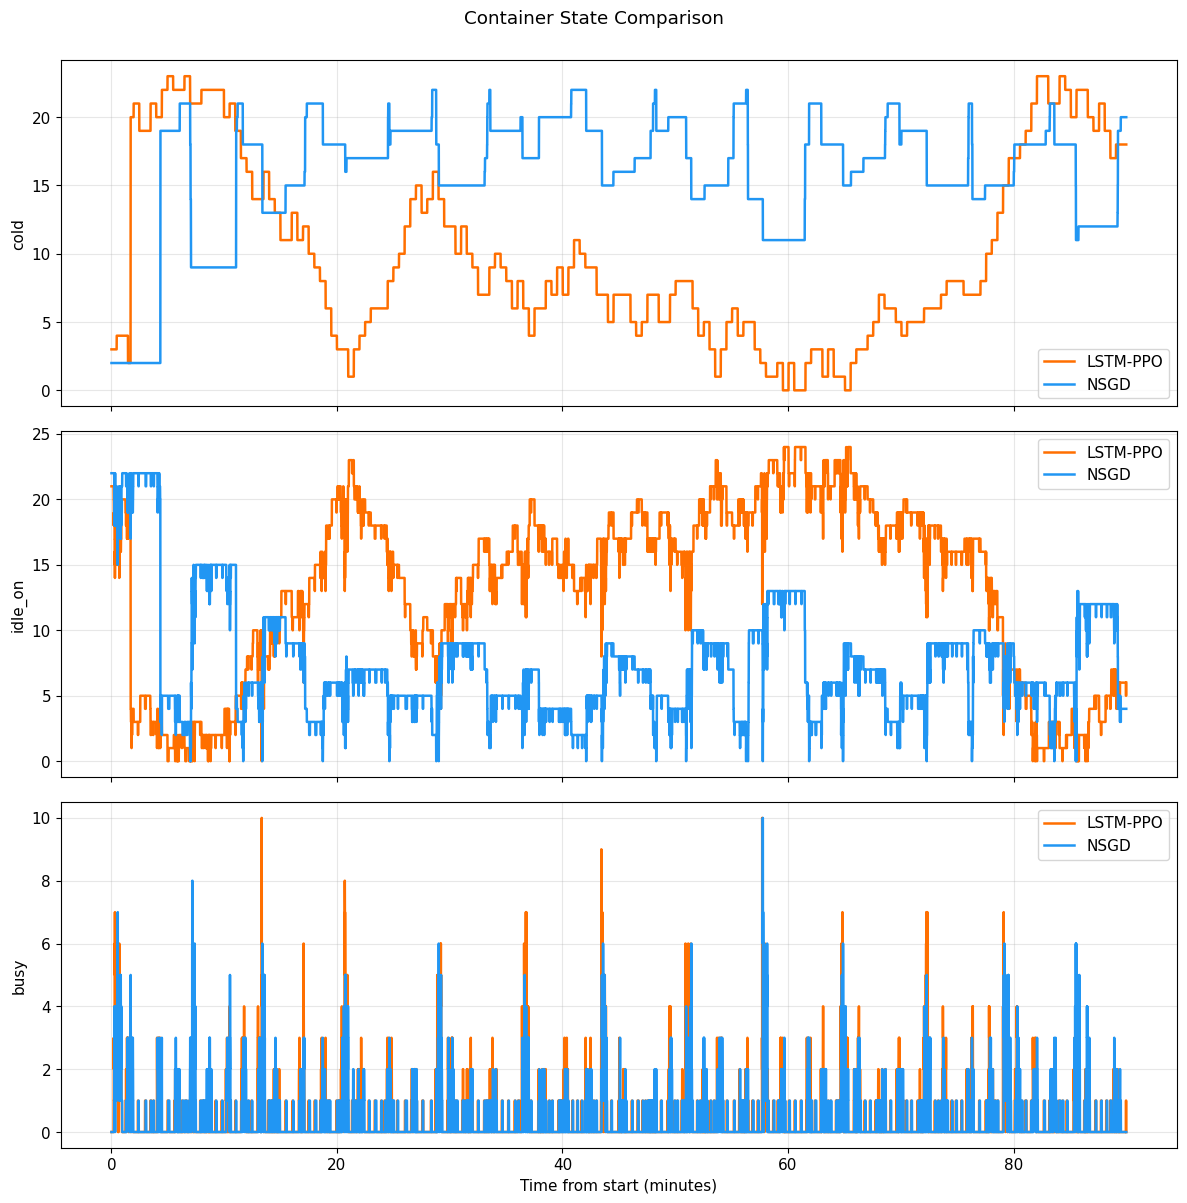

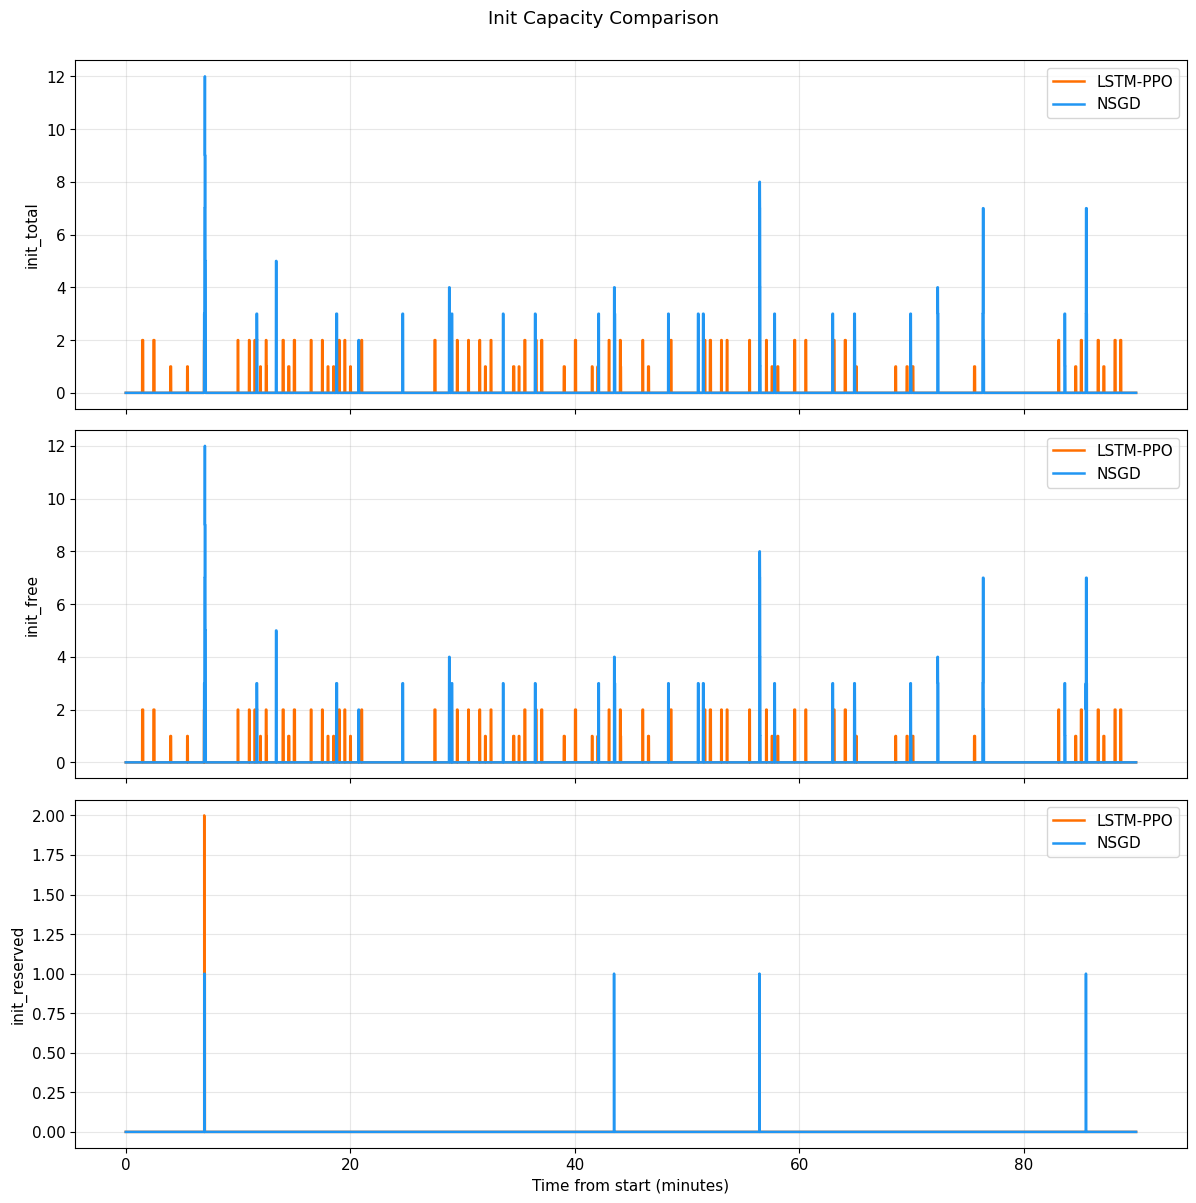

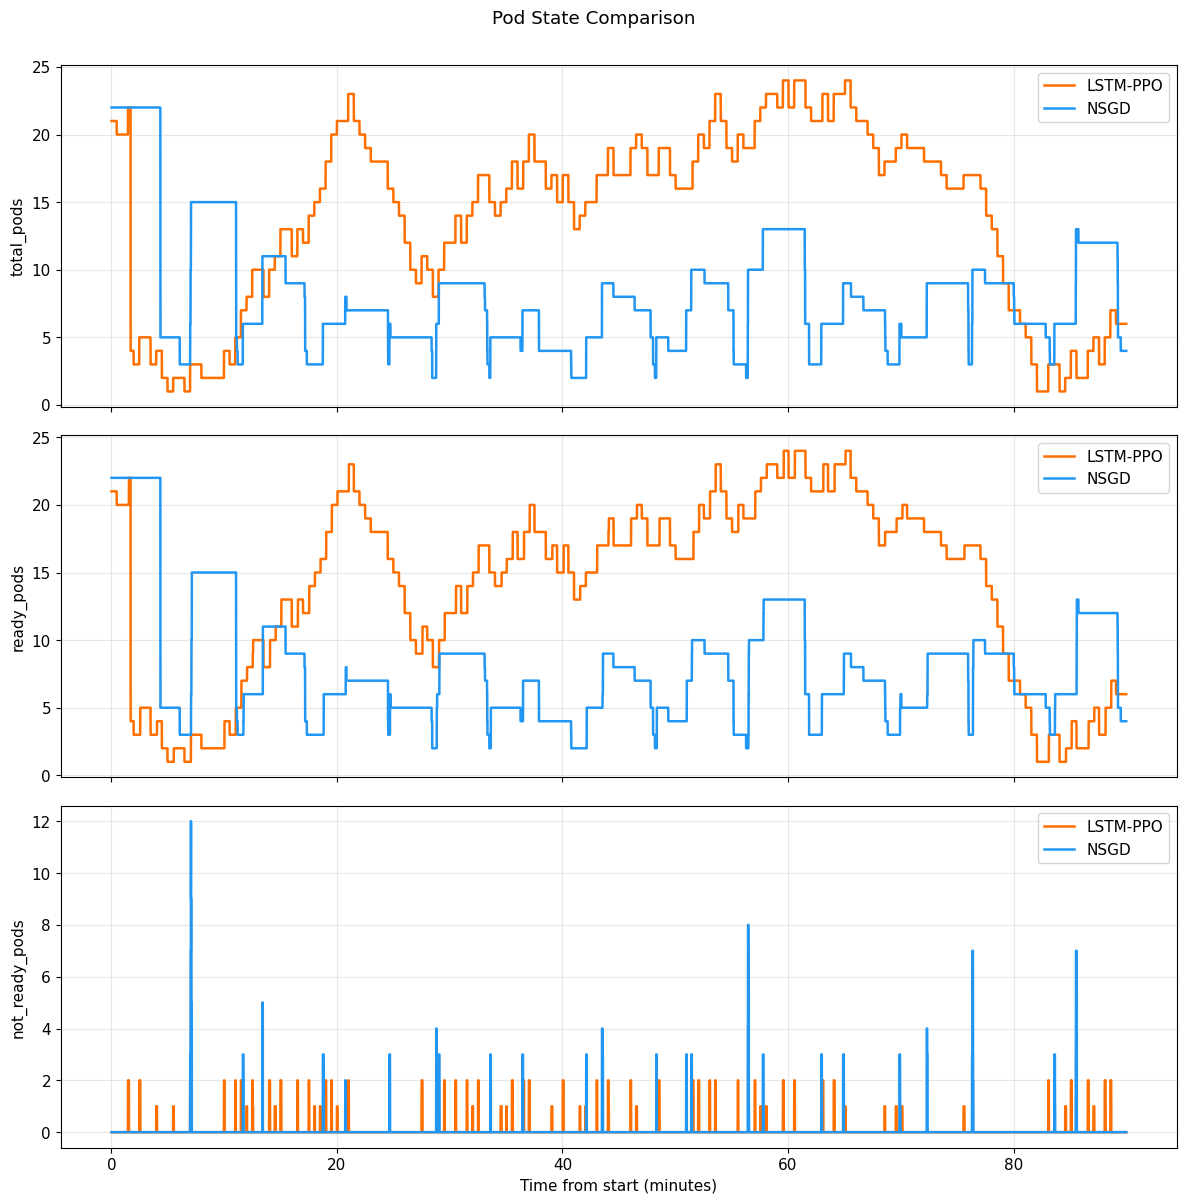

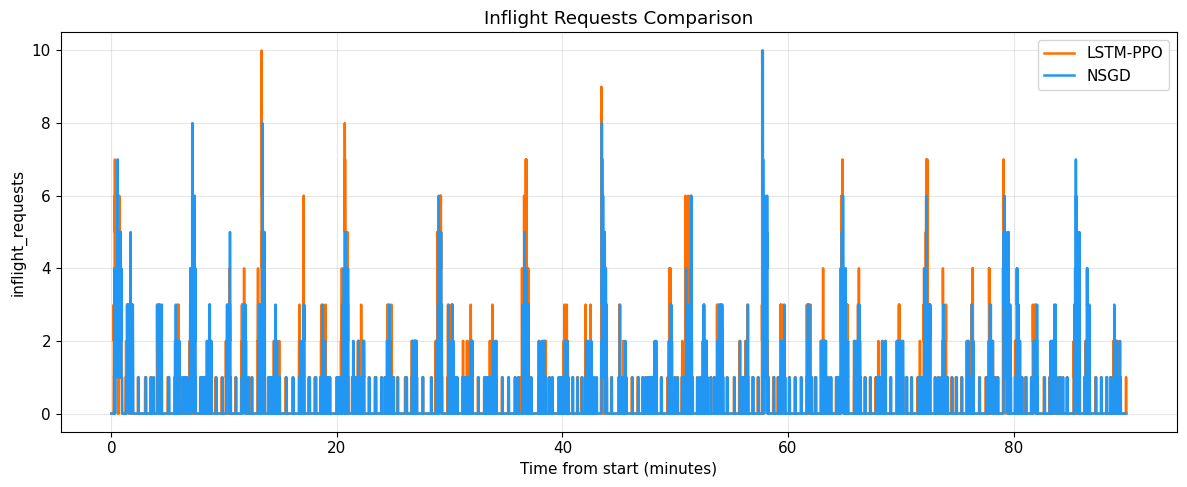

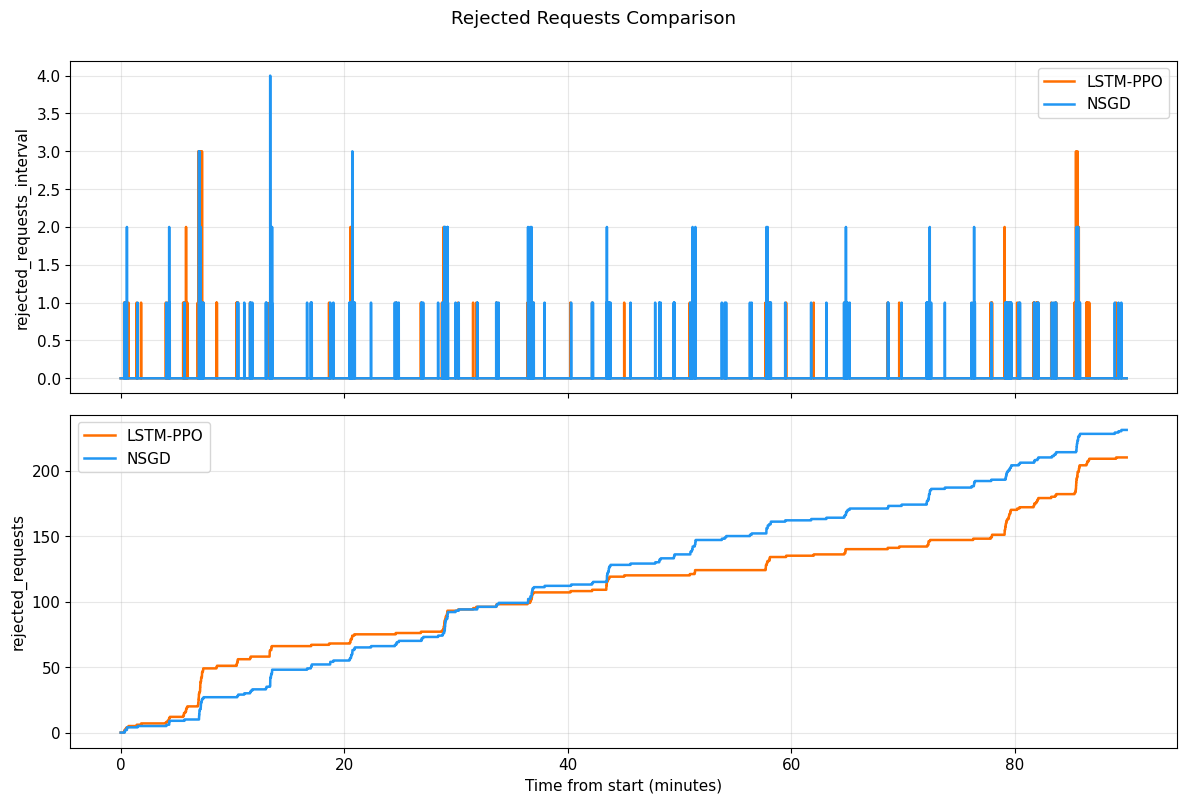

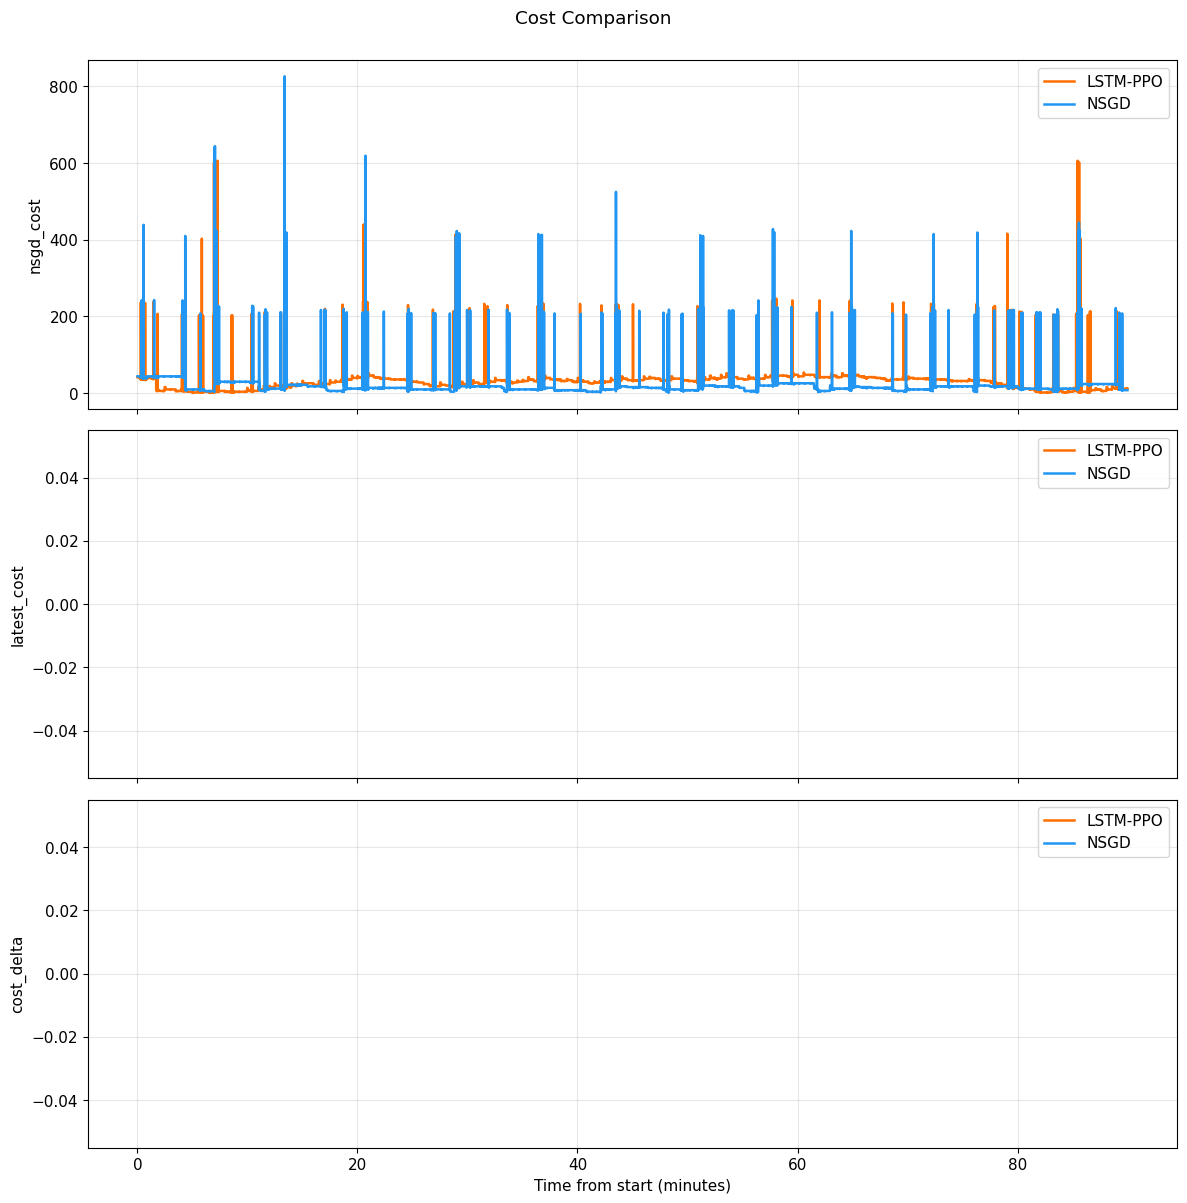

In [52]:
plot_metric_group(['cold', 'idle_on', 'busy'], 'Container State Comparison', 'containers_comparison.png')
plot_metric_group(['init_total', 'init_free', 'init_reserved'], 'Init Capacity Comparison', 'init_comparison.png')
plot_metric_group(['total_pods', 'ready_pods', 'not_ready_pods'], 'Pod State Comparison', 'pods_comparison.png')
plot_metric('inflight_requests', 'Inflight Requests Comparison', 'inflight_requests', 'inflight_requests_comparison.png')
plot_metric_group(['rejected_requests_interval', 'rejected_requests'], 'Rejected Requests Comparison', 'rejections_comparison.png')
plot_metric_group(['nsgd_cost', 'latest_cost', 'cost_delta'], 'Cost Comparison', 'cost_comparison.png')

## Monitor-Derived Throughput Comparison

The notebook uses only `monitor.csv`, so throughput is inferred from monitor state changes rather than request logs. For each monitor sample, the throughput proxy counts completed in-flight work as the positive decrease in `inflight_requests`:

`throughput_proxy_interval = max(-diff(inflight_requests), 0)`

The line chart buckets those inferred completion events and reports them as events per minute. This is a monitor-derived throughput proxy: it captures state-change behavior from the monitor stream, but simultaneous arrivals and completions inside the same sampling interval can cancel each other out.

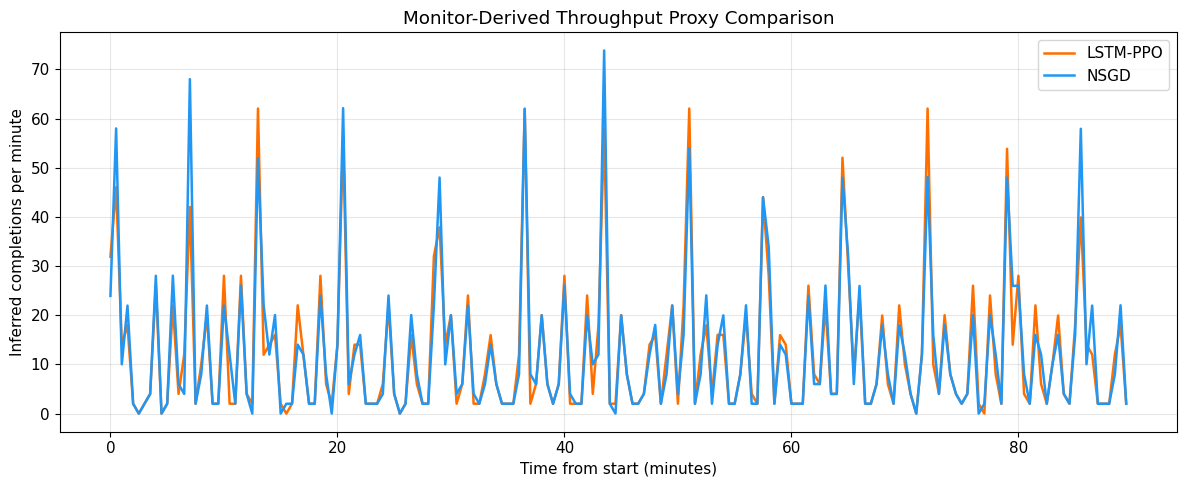

In [53]:
lstm_bucketed = bucket_monitor_events(lstm)
nsgd_bucketed = bucket_monitor_events(nsgd)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lstm_bucketed['minutes_from_start'], lstm_bucketed['throughput_proxy_per_min'], color=COLOR_LSTM, label=LABEL_LSTM)
ax.plot(nsgd_bucketed['minutes_from_start'], nsgd_bucketed['throughput_proxy_per_min'], color=COLOR_NSGD, label=LABEL_NSGD)
ax.set_title('Monitor-Derived Throughput Proxy Comparison')
ax.set_xlabel('Time from start (minutes)')
ax.set_ylabel('Inferred completions per minute')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'throughput_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [54]:
throughput_text = pd.DataFrame({
    'dataset': [LABEL_LSTM, LABEL_NSGD],
    'average_throughput_proxy_per_min': [
        lstm_bucketed['throughput_proxy_per_min'].mean(),
        nsgd_bucketed['throughput_proxy_per_min'].mean(),
    ],
    'total_throughput_proxy_events': [
        lstm_bucketed['throughput_proxy_events'].sum(),
        nsgd_bucketed['throughput_proxy_events'].sum(),
    ],
})
display(throughput_text.round(3))

,dataset,average_throughput_proxy_per_min,total_throughput_proxy_events
0,LSTM-PPO,12.511,1126.0
1,NSGD,12.711,1144.0


## Total Rejected Function Calls

Rejected function calls are calculated directly from `rejected_requests_interval` in `monitor.csv`:

`total_rejected_function_calls = cumulative_sum(rejected_requests_interval)`

The chart shows cumulative rejected calls over time and labels the final total for each dataset.

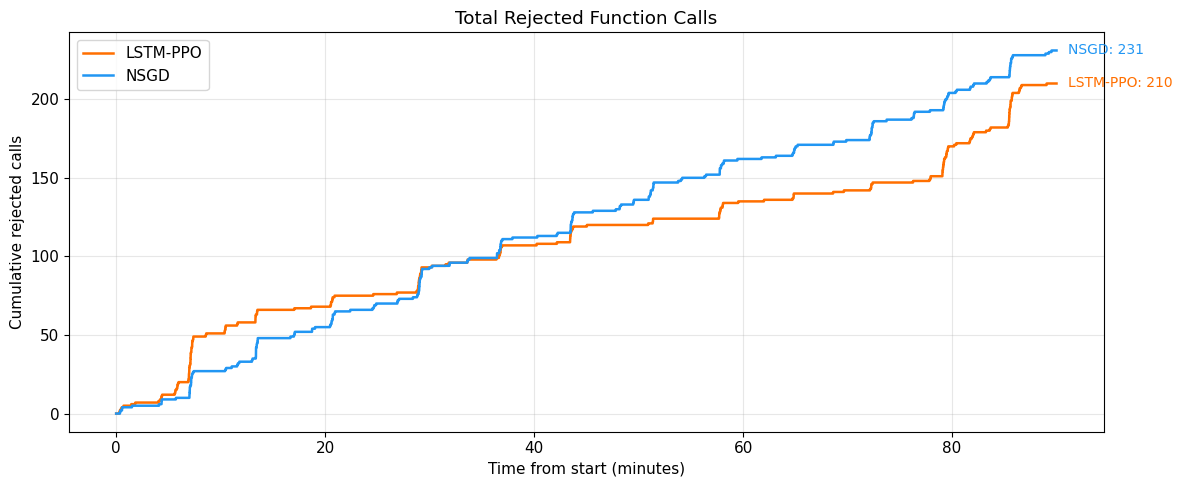

In [55]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lstm['minutes_from_start'], lstm['monitor_total_rejected_calls'], color=COLOR_LSTM, label=LABEL_LSTM)
ax.plot(nsgd['minutes_from_start'], nsgd['monitor_total_rejected_calls'], color=COLOR_NSGD, label=LABEL_NSGD)
annotate_last_value(ax, lstm, 'monitor_total_rejected_calls', COLOR_LSTM, LABEL_LSTM)
annotate_last_value(ax, nsgd, 'monitor_total_rejected_calls', COLOR_NSGD, LABEL_NSGD)
ax.set_title('Total Rejected Function Calls')
ax.set_xlabel('Time from start (minutes)')
ax.set_ylabel('Cumulative rejected calls')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'total_rejected_function_calls.png'), dpi=150, bbox_inches='tight')
plt.show()

## Cost Comparison Line Chart

Cost is read from `latest_cost` when that monitor column has valid data. If not, the notebook falls back to `nsgd_cost`; if neither cost column is usable, it recomputes a monitor-only cost:

`cost = 2*idle_on + 1*busy + 5*init_total + 100*init_reserved + 200*rejected_requests_interval`

The mean cost values are printed in the next code block instead of being written on the chart.

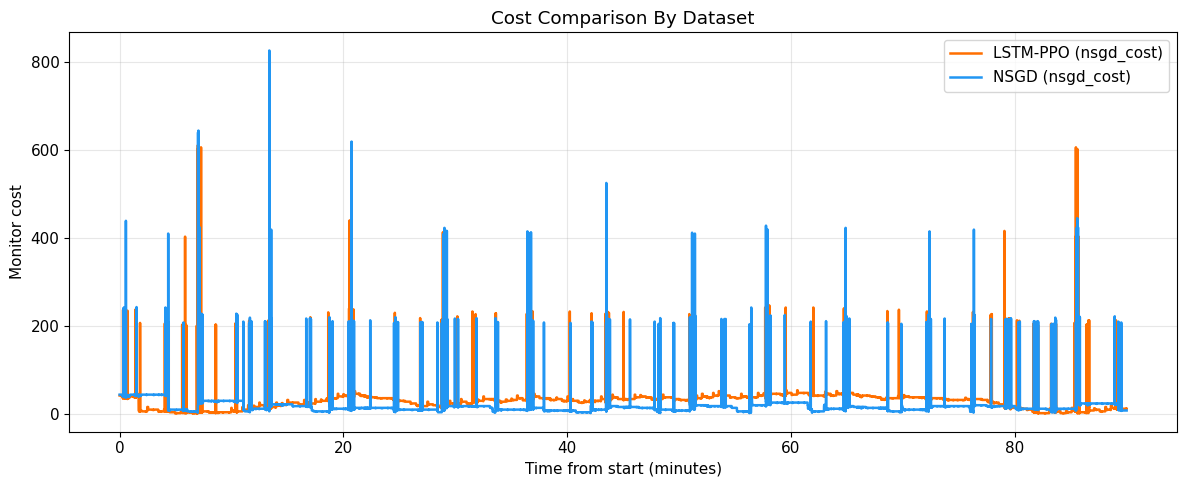

In [56]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lstm['minutes_from_start'], lstm['monitor_cost_for_comparison'], color=COLOR_LSTM, label=f'{LABEL_LSTM} ({lstm["monitor_cost_source"].iloc[0]})')
ax.plot(nsgd['minutes_from_start'], nsgd['monitor_cost_for_comparison'], color=COLOR_NSGD, label=f'{LABEL_NSGD} ({nsgd["monitor_cost_source"].iloc[0]})')
ax.set_title('Cost Comparison By Dataset')
ax.set_xlabel('Time from start (minutes)')
ax.set_ylabel('Monitor cost')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'cost_comparison_linechart.png'), dpi=150, bbox_inches='tight')
plt.show()

In [57]:
cost_text = pd.DataFrame({
    'dataset': [LABEL_LSTM, LABEL_NSGD],
    'cost_source': [
        lstm['monitor_cost_source'].iloc[0],
        nsgd['monitor_cost_source'].iloc[0],
    ],
    'average_monitor_cost': [
        lstm['monitor_cost_for_comparison'].mean(),
        nsgd['monitor_cost_for_comparison'].mean(),
    ],
})
display(cost_text.round(3))

,dataset,cost_source,average_monitor_cost
0,LSTM-PPO,nsgd_cost,28.471
1,NSGD,nsgd_cost,16.818


## Cold Start Events From Monitor State Changes

Because this notebook only uses `monitor.csv`, cold starts are inferred from increases in the sampled `cold` state count:

`cold_start_events_interval = max(diff(cold), 0)`

This treats every positive increase in cold pods as a cold-start event and ignores decreases, which represent pods leaving the cold state.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lstm['minutes_from_start'], lstm['total_cold_start_events'], color=COLOR_LSTM, label=LABEL_LSTM)
ax.plot(nsgd['minutes_from_start'], nsgd['total_cold_start_events'], color=COLOR_NSGD, label=LABEL_NSGD)
annotate_last_value(ax, lstm, 'total_cold_start_events', COLOR_LSTM, LABEL_LSTM)
annotate_last_value(ax, nsgd, 'total_cold_start_events', COLOR_NSGD, LABEL_NSGD)
ax.set_title('Cold Start Events From Monitor State Changes')
ax.set_xlabel('Time from start (minutes)')
ax.set_ylabel('Cumulative cold start events')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'cold_start_events_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Pod Change Events

Pod changes are also monitor events. The notebook counts them from absolute changes in pod-state columns:

`pod_change_events = abs(diff(total_pods)) + abs(diff(ready_pods)) + abs(diff(not_ready_pods))`

The chart shows cumulative pod state-change events for each dataset.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lstm['minutes_from_start'], lstm['total_pod_change_events'], color=COLOR_LSTM, label=LABEL_LSTM)
ax.plot(nsgd['minutes_from_start'], nsgd['total_pod_change_events'], color=COLOR_NSGD, label=LABEL_NSGD)
annotate_last_value(ax, lstm, 'total_pod_change_events', COLOR_LSTM, LABEL_LSTM)
annotate_last_value(ax, nsgd, 'total_pod_change_events', COLOR_NSGD, LABEL_NSGD)
ax.set_title('Pod State Change Events')
ax.set_xlabel('Time from start (minutes)')
ax.set_ylabel('Cumulative pod change events')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pod_change_events_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Aggregate Bar Comparison

In [ ]:
bar_metrics = [
    'mean_cold',
    'mean_busy',
    'mean_ready_pods',
    'max_inflight_requests',
    'total_rejected_interval',
    'final_rejected_requests',
    'final_latest_cost',
    'mean_monitor_cost',
    'total_rejected_function_calls',
    'total_cold_start_events',
    'total_pod_change_events',
    'total_cost_delta',
]
bar_metrics = [metric for metric in bar_metrics if metric in summary.columns]

fig, axes = plt.subplots(len(bar_metrics), 1, figsize=(10, 4 * len(bar_metrics)))
if len(bar_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, bar_metrics):
    values = pd.to_numeric(summary[metric], errors='coerce')
    bars = ax.bar(values.index, values.values, color=[COLOR_LSTM, COLOR_NSGD])
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylabel(metric)
    for bar, value in zip(bars, values.values):
        if pd.isna(value):
            continue
        label = f'{value:,.2f}' if abs(value) < 100 else f'{value:,.0f}'
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
        )
    if values.dropna().size:
        top = values.max()
        bottom = values.min()
        padding = (top - bottom) * 0.15 if top != bottom else abs(top) * 0.15 + 1
        ax.set_ylim(bottom=min(0, bottom), top=top + padding)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'summary_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

## Phase-Based Comparison

In [ ]:
phase_metrics = available_columns([
    'cold',
    'busy',
    'ready_pods',
    'inflight_requests',
    'rejected_requests_interval',
    'latest_cost',
])

if 'phase' not in combined.columns or not phase_metrics:
    print('Skipping phase comparison: phase column or phase metrics are missing')
else:
    phase_source = combined[['dataset', 'phase'] + phase_metrics].copy()
    for metric in phase_metrics:
        phase_source[metric] = pd.to_numeric(phase_source[metric], errors='coerce')

    phase_summary = phase_source.groupby(['dataset', 'phase'])[phase_metrics].mean().round(3)
    display(phase_summary)

    for metric in phase_metrics:
        pivot = phase_summary[metric].unstack('dataset')
        pivot = pivot.apply(pd.to_numeric, errors='coerce').dropna(how='all')
        if pivot.empty:
            print(f'Skipping phase {metric}: no numeric data to plot')
            continue
        ax = pivot.plot(kind='bar', figsize=(12, 5), color=[COLOR_LSTM, COLOR_NSGD])
        ax.set_title(f'{metric} by phase')
        ax.set_xlabel('Phase')
        ax.set_ylabel(metric)
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f'phase_{metric}.png'), dpi=150, bbox_inches='tight')
        plt.show()

## Data-Driven Interpretation

In [ ]:
def lower_is_better(metric):
    values = summary[metric].dropna()
    if len(values) < 2:
        return f'{metric}: insufficient data'
    best = values.idxmin()
    return f'{metric}: lower for {best} ({values[best]:.3f})'


def higher_is_better(metric):
    values = summary[metric].dropna()
    if len(values) < 2:
        return f'{metric}: insufficient data'
    best = values.idxmax()
    return f'{metric}: higher for {best} ({values[best]:.3f})'


interpretation = [
    lower_is_better('total_rejected_interval'),
    lower_is_better('final_rejected_requests'),
    lower_is_better('mean_cold'),
    lower_is_better('mean_inflight_requests'),
    lower_is_better('final_latest_cost'),
    higher_is_better('mean_ready_pods'),
]

for line in interpretation:
    print(line)

print(f'Figures saved in: {OUT_DIR}')